## Лабораторна робота №1 “Linear Regression”
#### Мета: навчитись реалізовувати лінійну регресію та градієнтний спуск.
#### Завдання:

1. Викачати дані з https://drive.google.com/drive/folders/17Xwk2quPb1gFmjG3KVIoZqChrWdcZ8XS?usp=sharing

In [34]:
import numpy as np
import matplotlib.pyplot as plt

train_data = np.loadtxt('lab_1_train.csv', delimiter=',', skiprows=1)
test_data = np.loadtxt('lab_1_test.csv', delimiter=',', skiprows=1)

train_X = train_data[:, 1]
train_y = train_data[:, 2]

test_X = test_data[:, 1]
test_y = test_data[:, 2]

2. Реалізувати лінійну регресію, яка за допомогою даних з колонки “x” прогнозує значення в колонці “y” (перша колонка у файлах - просто індекс, не ознака, не потрібно її використовувати). Тренування алгоритму повинно відбуватись лише на даних з train датасету. Test датасет слугує для перевірки якості вже натренованої моделі.

    a) Візуалізувати дані з lab1_train.csv.

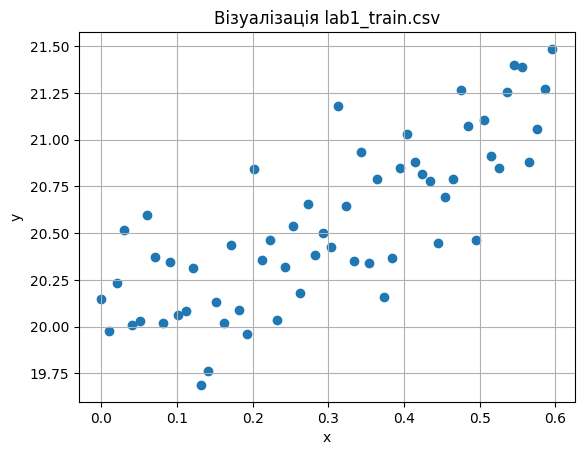

In [35]:
plt.scatter(train_X, train_y)
plt.title('Візуалізація lab1_train.csv')
plt.xlabel('x'); plt.ylabel('y')
plt.grid()
plt.show()

    b) Після кожної епохи виводити поточні значення ваг та функції втрат. Використовувати Mean Squared Error як функцію втрат.

In [36]:
def gradient_desc(train_X, train_y, alpha):
    b0 = b1 = 0.0
    J_eps = 0.000001
    prev_J = float('inf')
    m = len(train_X)
    epoch = 0 
    
    print("Початок градієнтного спуску:")
    while True:
        pred_y = b0 + b1 * train_X
        
        e =  pred_y - train_y
        J = (1 / (2 * m)) * np.sum(e ** 2)
        
        print(f"Епоха {epoch}: b0 = {b0:.5f}, b1 = {b1:.5f}, J = {J:.5f}")
        
    
        if abs(prev_J - J) < J_eps:
            print(f"Умова збіжності виконана на епосі {epoch}")
            break
            
        prev_J = J
        
        dJ_db0 = (1 / m) * np.sum(e)
        dJ_db1 = (1 / m) * np.sum(e * train_X)
        
        b0 = b0 - alpha * dJ_db0
        b1 = b1 - alpha * dJ_db1
        
        epoch += 1
        
    return b0, b1, J

b0_base, b1_base, J_base = gradient_desc(train_X, train_y, 0.5)

Початок градієнтного спуску:
Епоха 0: b0 = 0.00000, b1 = 0.00000, J = 211.23870
Епоха 1: b0 = 10.27478, b1 = 3.09195, J = 43.79892
Епоха 2: b0 = 14.95150, b1 = 4.46849, J = 9.23304
Епоха 3: b0 = 17.08477, b1 = 5.06607, J = 2.09376
Епоха 4: b0 = 18.06238, b1 = 5.31014, J = 0.61572
Епоха 5: b0 = 18.51481, b1 = 5.39398, J = 0.30633
Епоха 6: b0 = 18.72854, b1 = 5.40542, J = 0.23829
Епоха 7: b0 = 18.83370, b1 = 5.38432, J = 0.22018
Епоха 8: b0 = 18.88942, b1 = 5.34882, J = 0.21248
Епоха 9: b0 = 18.92257, b1 = 5.30714, J = 0.20705
Епоха 10: b0 = 18.94536, b1 = 5.26300, J = 0.20219
Епоха 11: b0 = 18.96333, b1 = 5.21811, J = 0.19756
Епоха 12: b0 = 18.97900, b1 = 5.17321, J = 0.19307
Епоха 13: b0 = 18.99352, b1 = 5.12867, J = 0.18871
Епоха 14: b0 = 19.00742, b1 = 5.08461, J = 0.18447
Епоха 15: b0 = 19.02094, b1 = 5.04112, J = 0.18035
Епоха 16: b0 = 19.03417, b1 = 4.99821, J = 0.17635
Епоха 17: b0 = 19.04719, b1 = 4.95589, J = 0.17245
Епоха 18: b0 = 19.06000, b1 = 4.91416, J = 0.16867
Епоха 19: 

Коефіцієнт альфа підібраний випадково, що призвело до великої кількості епох.

Тепер спробуємо визначити за якого альфа J буде найменше.

Найкраще значення alpha = 1.3034, J = 0.0365


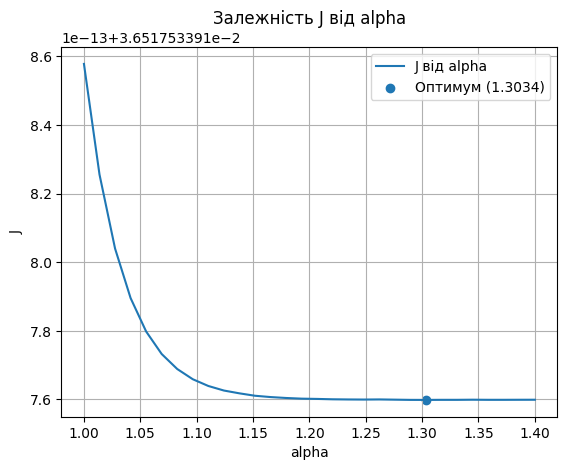

In [37]:
alphas = np.linspace(1, 1.4, 30)
J_results = []
epochs_max = 500

for a in alphas:
    b0 = b1 = 0.0
    
    for epoch in range(epochs_max):
        m = len(train_X)
        pred_y = b0 + b1 * train_X
        e = pred_y - train_y
        
        dJ_db0 = (1 / m) * np.sum(e)
        dJ_db1 = (1 / m) * np.sum(e * train_X)
        
        b0 = b0 - a * dJ_db0
        b1 = b1 - a * dJ_db1
        
    pred_y = b0 + b1 * train_X
    J = (1 / (2 * m)) * np.sum((pred_y - train_y) ** 2)
    
    J_results.append(J)

best_idx = np.argmin(J_results)
best_alpha = alphas[best_idx]
best_J = J_results[best_idx]

print(f"Найкраще значення alpha = {best_alpha:.4f}, J = {best_J:.4f}")

plt.plot(alphas, J_results, label='J від alpha')
plt.scatter(best_alpha, best_J, label=f'Оптимум ({best_alpha:.4f})')

plt.title('Залежність J від alpha')
plt.xlabel('alpha')
plt.ylabel('J')
plt.legend()
plt.grid()
plt.show()

Підставимо ідеальне альфа в функцію градієнтного спуску:

In [38]:
b0, b1, J = gradient_desc(train_X, train_y, 1.3034)

Початок градієнтного спуску:
Епоха 0: b0 = 0.00000, b1 = 0.00000, J = 211.23870
Епоха 1: b0 = 26.78430, b1 = 8.06010, J = 37.89680
Епоха 2: b0 = 15.52751, b1 = 4.46325, J = 6.94676
Епоха 3: b0 = 20.33979, b1 = 5.79812, J = 1.41179
Епоха 4: b0 = 18.36129, b1 = 5.05624, J = 0.41372
Епоха 5: b0 = 19.24971, b1 = 5.19822, J = 0.22613
Епоха 6: b0 = 18.92502, b1 = 4.97307, J = 0.18387
Епоха 7: b0 = 19.11098, b1 = 4.90905, J = 0.16819
Епоха 8: b0 = 19.07942, b1 = 4.78278, J = 0.15783
Епоха 9: b0 = 19.13804, b1 = 4.68841, J = 0.14896
Епоха 10: b0 = 19.15690, b1 = 4.58596, J = 0.14086
Епоха 11: b0 = 19.19097, b1 = 4.49212, J = 0.13337
Епоха 12: b0 = 19.21708, b1 = 4.39966, J = 0.12642
Епоха 13: b0 = 19.24507, b1 = 4.31144, J = 0.11997
Епоха 14: b0 = 19.27084, b1 = 4.22608, J = 0.11398
Епоха 15: b0 = 19.29617, b1 = 4.14400, J = 0.10842
Епоха 16: b0 = 19.32037, b1 = 4.06485, J = 0.10326
Епоха 17: b0 = 19.34377, b1 = 3.98862, J = 0.09847
Епоха 18: b0 = 19.36627, b1 = 3.91516, J = 0.09403
Епоха 19: 

c) Після того, як градієнтний спуск зійшовся, порахувати функцію втрат на тестових даних з lab1_test.csv.

In [39]:
pred_test_y = b0 + b1 * test_X
test_J = (1 / (2 * m)) * np.sum((test_y - pred_test_y) ** 2)
print(f"J на lab1_test.csv: {test_J:.5f}")

J на lab1_test.csv: 0.02483


d) Візуалізувати на одному графіку дані з lab1_train.csv,  lab1_test.csv та лінію, до якої зійшовся розв’язок.

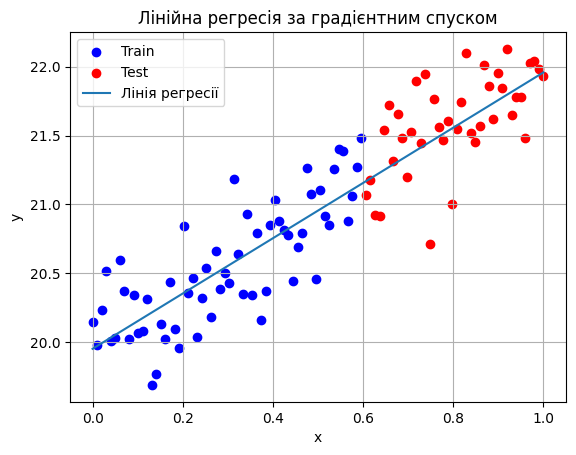

In [40]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')

x_min = min(np.min(train_X), np.min(test_X))
x_max = max(np.max(train_X), np.max(test_X))
x_line = np.array([x_min, x_max])
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, label='Лінія регресії')
plt.title('Лінійна регресія за градієнтним спуском')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

## Метод Оптимально Визначння Вагів:

In [41]:
b1_opt = (np.sum(train_X * train_y) - (1 / m) * np.sum(train_X) * np.sum(train_y)) / (np.sum(train_X ** 2) - (1 / m) * (np.sum(train_X) ** 2))
b0_opt = np.mean(train_y) - b1_opt * np.mean(train_X)

print(f"b0_opt = {b0_opt:.5f}, b1_opt = {b1_opt:.5f}")

b0_opt = 19.95993, b1_opt = 1.97878


Порівняння оптимального і градієнтного методів визначення вагів.

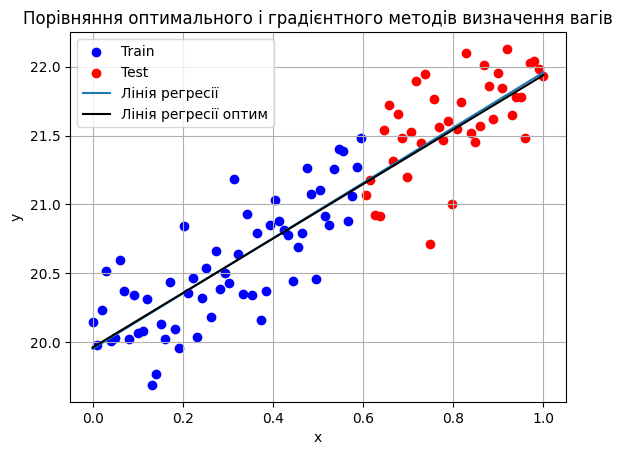

In [44]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')
y_line_opt = b0_opt + b1_opt * x_line

plt.plot(x_line, y_line, label='Лінія регресії')
plt.plot(x_line, y_line_opt, color='black', label='Лінія регресії оптим')
plt.title('Порівняння оптимального і градієнтного методів визначення вагів')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

## Висновок:

У ході виконання лабораторної роботи було успішно реалізовано алгоритм лінійної регресії. Під час роботи було налагоджено процес обчислення функції втрат та ітеративне оновлення ваг моделі, а також практично доведено важливість правильного підбору кроку alpha для успішного сходження алгоритму до глобального мінімуму. Обчислення похибки на тестовій вибірці та підсумкова візуалізація підтвердили, що побудована модель не лише мінімізувала помилку на тренувальних даних, але й здатна точно прогнозувати значення на нових, невідомих алгоритму даних.